# Mobil Phones Price Classification with Machine Learning

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQxoBz-JQ21Xdz0Rd6aoYkoUkmSLwsPTMayOQ&s'>

🇹🇷 Türkçe
Bu çalışmanın amacı, telefonların teknik özelliklerini kullanarak fiyat aralığını (0: düşük maliyet, 3: çok yüksek maliyet) tahmin edebilen bir sınıflandırma modeli geliştirmektir. Böylece, yeni bir telefonun fiyat kategorisi, mevcut özelliklerine göre hızlı ve doğru bir şekilde öngörülebilir.

🇬🇧 English
The purpose of this study is to develop a classification model that can predict the price range of phones (0: low cost, 3: very high cost) based on their technical features. This allows the price category of a new phone to be quickly and accurately estimated from its specifications.

In [1]:
import pandas as pd
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [2]:
df=pd.read_csv('telephoneprice.csv')

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,14,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,3,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,3,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,5,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,16,483,754,3919,19,4,2,1,1,1,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [7]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

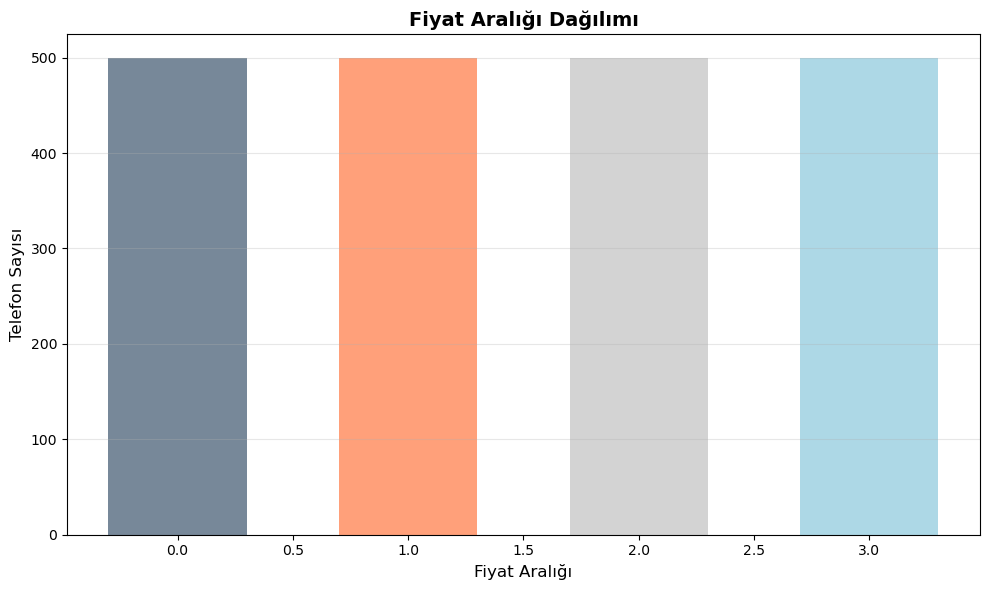

In [8]:
# Price Range Distribution
plt.figure(figsize=(10, 6))
price_counts = df['price_range'].value_counts().sort_index()
plt.bar(price_counts.index, price_counts.values, color=['#778899', '#FFA07A', '#D3D3D3', '#ADD8E6'], width=0.6)
plt.title('Fiyat Aralığı Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Fiyat Aralığı', fontsize=12)
plt.ylabel('Telefon Sayısı', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

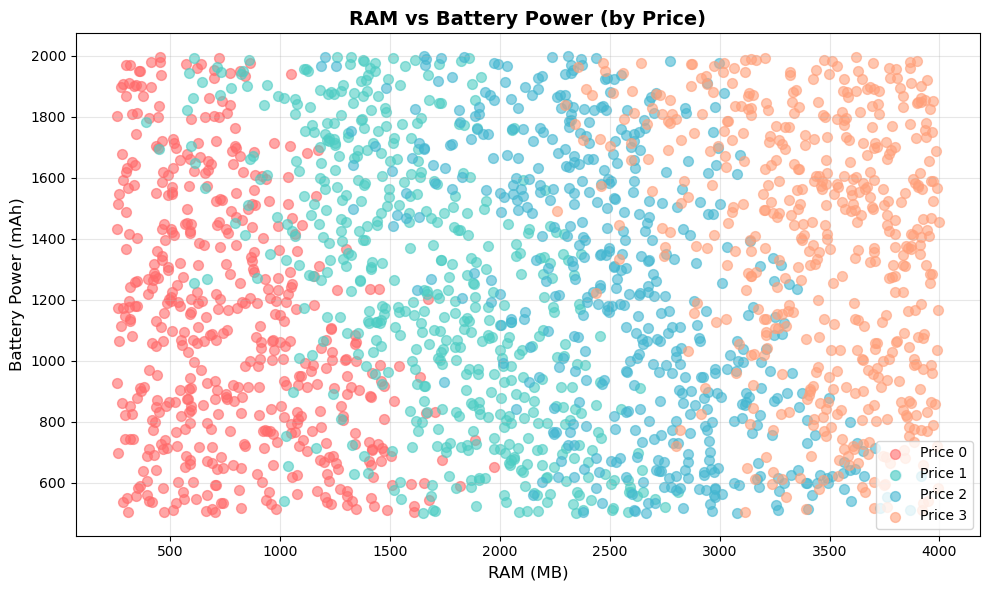

In [9]:
# RAM vs Price
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for price in sorted(df['price_range'].unique()):
    mask = df['price_range'] == price
    plt.scatter(df[mask]['ram'], df[mask]['battery_power'], 
                label=f'Price {price}', 
                alpha=0.6, s=50, color=colors[price])

plt.title('RAM vs Battery Power (by Price)', fontsize=14, fontweight='bold')
plt.xlabel('RAM (MB)', fontsize=12)
plt.ylabel('Battery Power (mAh)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

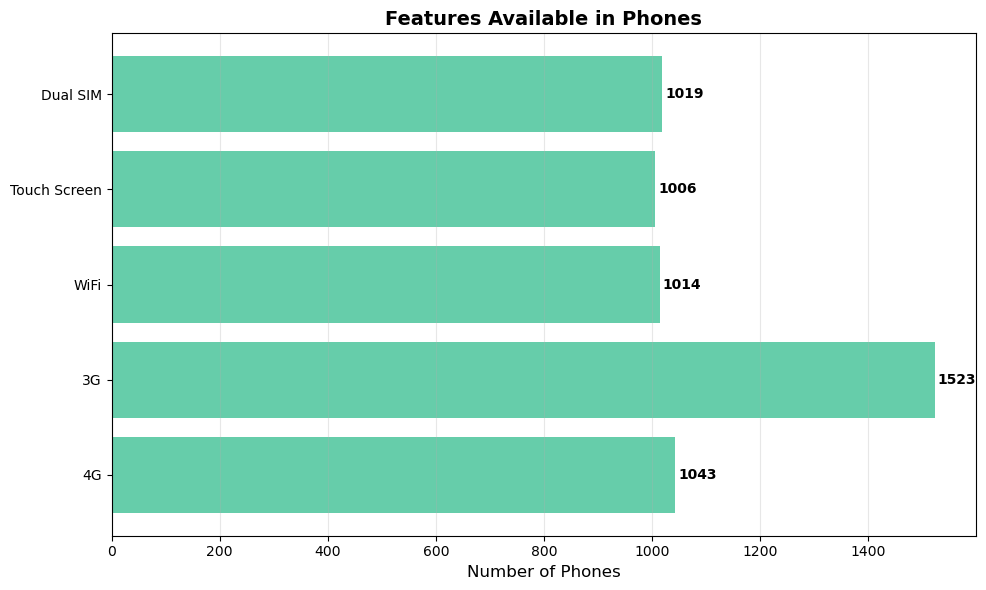

In [10]:
# Horizontal Bar
plt.figure(figsize=(10, 6))

features = ['4G', '3G', 'WiFi', 'Touch Screen', 'Dual SIM']
values = [df['four_g'].sum(), df['three_g'].sum(), df['wifi'].sum(), 
          df['touch_screen'].sum(), df['dual_sim'].sum()]

plt.barh(features, values, color='#66CDAA')
plt.title('Features Available in Phones', fontsize=14, fontweight='bold')
plt.xlabel('Number of Phones', fontsize=12)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(values):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

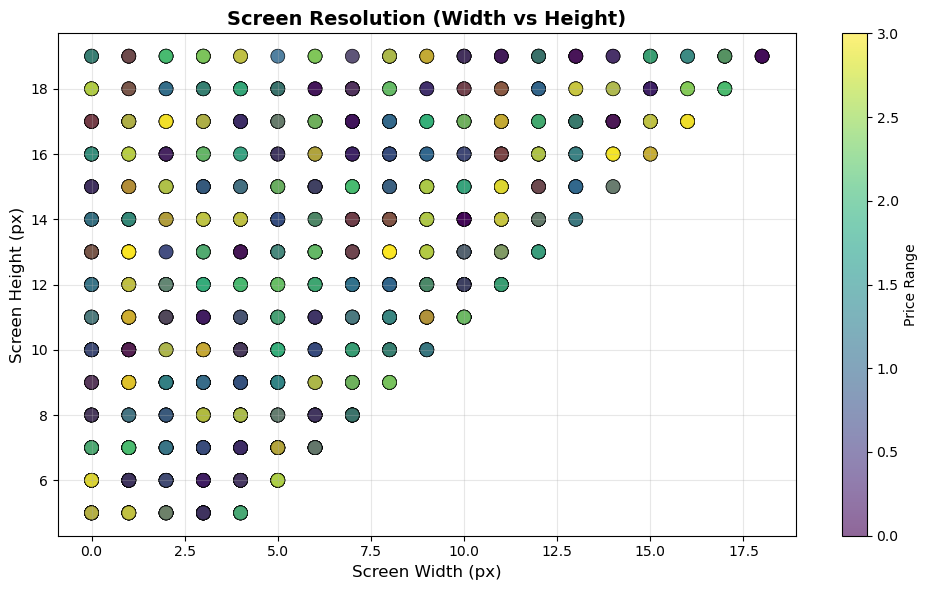

In [11]:
# Screen Size
plt.figure(figsize=(10, 6))

plt.scatter(df['sc_w'], df['sc_h'], 
            c=df['price_range'], cmap='viridis', 
            s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.title('Screen Resolution (Width vs Height)', fontsize=14, fontweight='bold')
plt.xlabel('Screen Width (px)', fontsize=12)
plt.ylabel('Screen Height (px)', fontsize=12)

cbar = plt.colorbar(label='Price Range')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

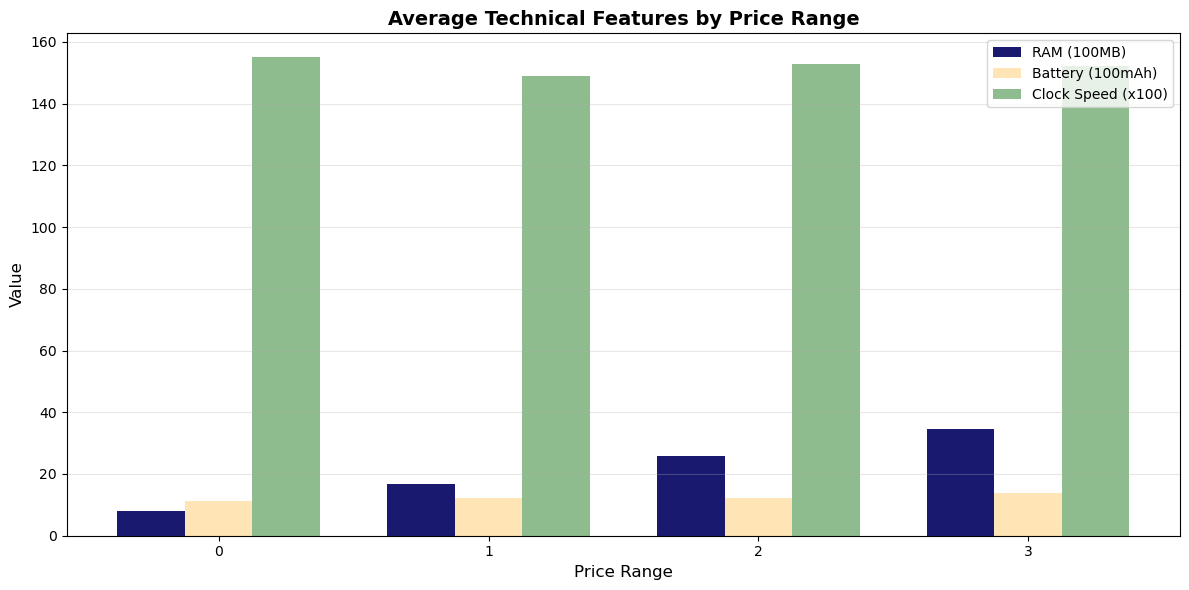

In [12]:
# Average Features by Price Range
plt.figure(figsize=(12, 6))
stats = df.groupby('price_range')[['ram', 'battery_power', 'clock_speed']].mean()
x = range(len(stats))
width = 0.25

plt.bar([i - width for i in x], stats['ram']/100, width, label='RAM (100MB)', color='#191970')
plt.bar(x, stats['battery_power']/100, width, label='Battery (100mAh)', color='#FFE4B5')
plt.bar([i + width for i in x], stats['clock_speed']*100, width, label='Clock Speed (x100)', color='#8FBC8F')

plt.title('Average Technical Features by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range', fontsize=12)
plt.ylabel('Value', fontsize=12)

plt.xticks(x, ['0', '1', '2', '3'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

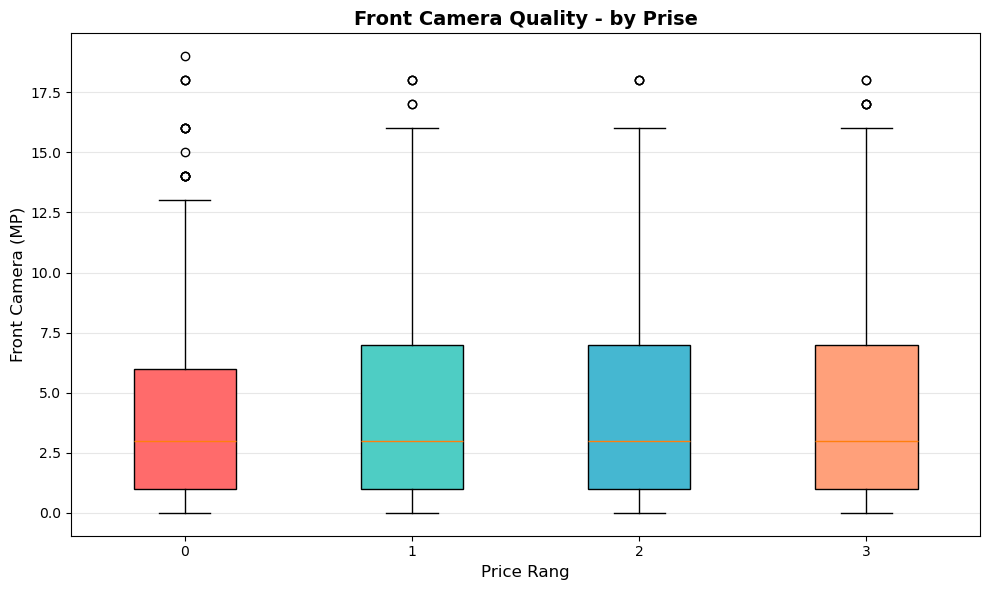

In [13]:
# Front Camera Quality vs Price
plt.figure(figsize=(10, 6))
data_to_plot = [df[df['price_range']==i]['fc'] for i in sorted(df['price_range'].unique())]
bp = plt.boxplot(data_to_plot, labels=['0', '1', '2', '3'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']):
    patch.set_facecolor(color)
plt.title('Front Camera Quality - by Prise', fontsize=14, fontweight='bold')
plt.xlabel('Price Rang', fontsize=12)
plt.ylabel('Front Camera (MP)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

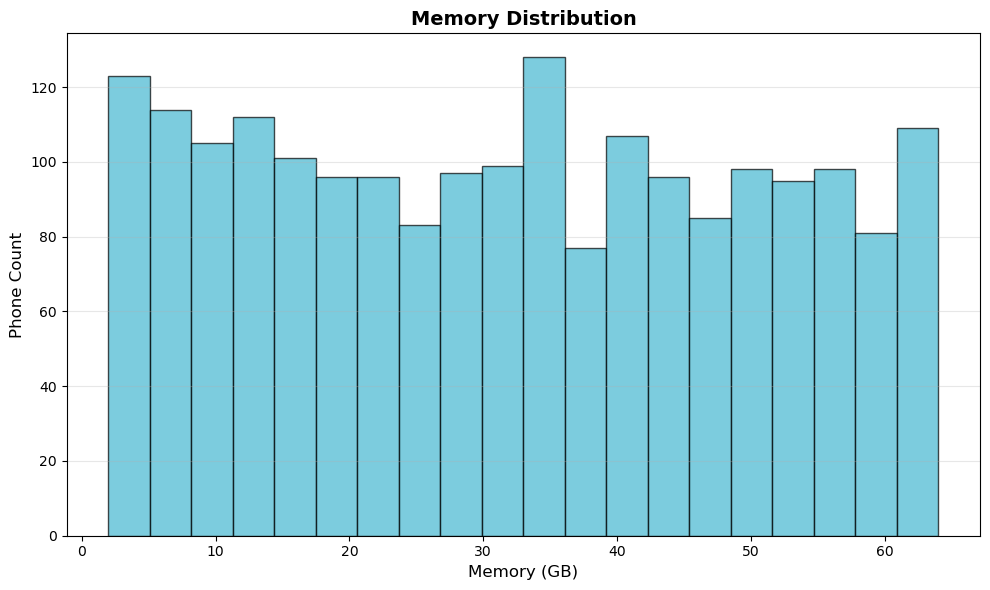

In [14]:
# Memory Distribution 
plt.figure(figsize=(10, 6))
plt.hist(df['int_memory'], bins=20, color='#45B7D1', edgecolor='black', alpha=0.7)
plt.title('Memory Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Memory (GB)', fontsize=12)
plt.ylabel('Phone Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
#Correlation by Salary
abs(df.corr(numeric_only=True))['price_range'].sort_values(ascending=False) 

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
touch_screen     0.030411
mobile_wt        0.030302
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
clock_speed      0.006606
n_cores          0.004399
m_dep            0.000853
Name: price_range, dtype: float64

In [16]:
# Battery efficiency
df['battery_per_weight'] = df['battery_power'] / df['mobile_wt']

In [17]:
# Camero Score 
df['camera_score'] = df['fc'] * df['pc']

In [18]:
# RAM/memory
df['ram_to_memory'] = df['ram'] / (df['int_memory'] + 1)

In [19]:
#Screen & Resolution
df['resolution'] = df['px_width'] * df['px_height']
df['screen_area'] = df['sc_w'] * df['sc_h']

In [20]:
df['ram_x_cores'] = df['ram'] * df['n_cores']

In [21]:
df['performance_score'] = (df['ram'] * 0.5 + df['clock_speed'] * 100 + df['n_cores'] * 50)

In [22]:
#Correlation by Salary
abs(df.corr(numeric_only=True))['price_range'].sort_values(ascending=False) 

price_range           1.000000
ram                   0.917046
performance_score     0.886541
ram_x_cores           0.614958
ram_to_memory         0.326595
battery_power         0.200723
battery_per_weight    0.177008
resolution            0.176240
px_width              0.165818
px_height             0.148858
int_memory            0.044435
screen_area           0.041248
sc_w                  0.038711
pc                    0.033599
touch_screen          0.030411
mobile_wt             0.030302
camera_score          0.026650
three_g               0.023611
sc_h                  0.022986
fc                    0.021998
talk_time             0.021859
blue                  0.020573
wifi                  0.018785
dual_sim              0.017444
four_g                0.014772
clock_speed           0.006606
n_cores               0.004399
m_dep                 0.000853
Name: price_range, dtype: float64

In [24]:
cols = [
    'ram',
    'performance_score',
    'ram_x_cores',
    'ram_to_memory',
    'battery_power',
    'battery_per_weight',
    'resolution',
    'px_width',
    'px_height'
]

x = df[cols]
y = df['price_range']

In [25]:
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.15)

In [26]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

In [27]:
g=GaussianNB()
b=BernoulliNB()

In [28]:
gmodel=g.fit(x_train,y_train)

In [29]:
gtahmin=gmodel.predict(x_test)

In [30]:
bmodel=b.fit(x_train,y_train)

In [31]:
btahmin=bmodel.predict(x_test)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_test, gtahmin)

0.7766666666666666

In [33]:
confusion_matrix(y_test,gtahmin)

array([[69, 11,  0,  0],
       [11, 53,  8,  0],
       [ 0, 10, 48, 10],
       [ 0,  1, 16, 63]])

In [34]:
print(classification_report(y_test,gtahmin))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        80
           1       0.71      0.74      0.72        72
           2       0.67      0.71      0.69        68
           3       0.86      0.79      0.82        80

    accuracy                           0.78       300
   macro avg       0.77      0.77      0.77       300
weighted avg       0.78      0.78      0.78       300



<Axes: >

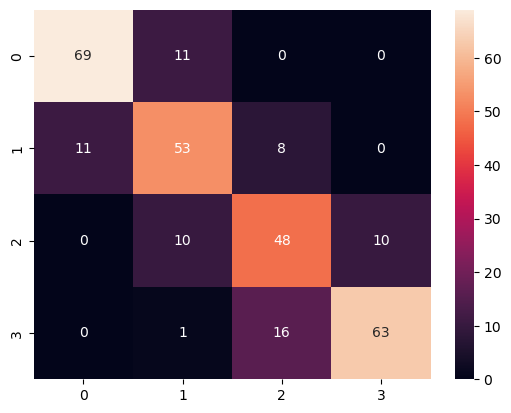

In [35]:
sns.heatmap(confusion_matrix(y_test,gtahmin), annot=True)

In [36]:
accuracy_score(y_test,btahmin)

0.22666666666666666

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [38]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[  0   0 105   0]
 [  0   0  91   0]
 [  0   0  92   0]
 [  0   0 112   0]]
LogisticRegression()  modeli eğitiliyor!..
[[71 28  5  1]
 [23 35 17 16]
 [ 3 27 20 42]
 [ 2  9 19 82]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[93 12  0  0]
 [ 3 82  6  0]
 [ 0 12 69 11]
 [ 0  0 13 99]]
RandomForestClassifier()  modeli eğitiliyor!..
[[ 98   7   0   0]
 [  3  86   2   0]
 [  0   7  78   7]
 [  0   0  11 101]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[ 99   6   0   0]
 [  3  84   4   0]
 [  0   9  77   6]
 [  0   0  12 100]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[60 28 13  4]
 [34 31 17  9]
 [23 29 22 18]
 [20 33 40 19]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[92 12  1  0]
 [24 43 24  0]
 [ 1 14 56 21]
 [ 0  0 17 95]]
MultinomialNB()  modeli eğitiliyor!..
[[54  8 21 22]
 [33 13 14 31]
 [12 14 11 55]
 [21 17 18 56]]
Eğitim tamamlandı.
En başarılı model:  RandomForestClassifier
Confusion Matrix:
[

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.9075,0.9075,0.9075,0.9075
GradientBoostingClassifier,0.9000,0.9000,0.9000,0.9000
DecisionTreeClassifier,0.8575,0.8575,0.8575,0.8575
AdaBoostClassifier,0.7150,0.7150,0.7150,0.7150
LogisticRegression,0.5200,0.5200,0.5200,0.5200
MultinomialNB,0.3350,0.3350,0.3350,0.3350
KNeighborsClassifier,0.3300,0.3300,0.3300,0.3300
BernoulliNB,0.2300,0.2300,0.2300,0.2300


In [39]:
sonuc=pd.DataFrame()

In [40]:
r=RandomForestClassifier()
r.fit(x_train, y_train)
tahmin=r.predict(x_test)

In [41]:
sonuc['price_range']=tahmin

In [42]:
sonuc

,price_range
0,0
1,2
2,1
3,3
4,1
...,...
295,1
296,1
297,0
298,1


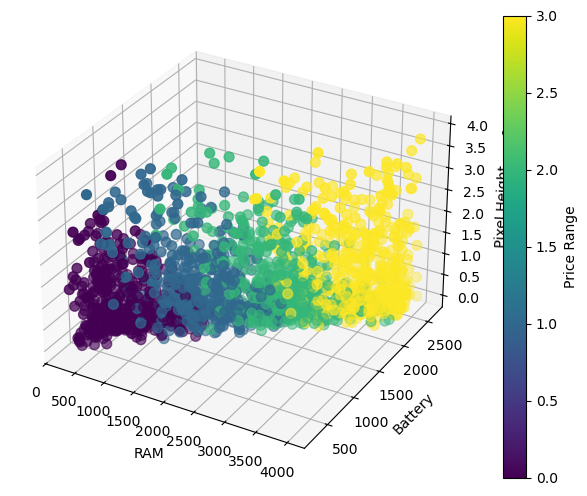

In [43]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(df['ram'], df['performance_score'], df['resolution'],
           c=df['price_range'], cmap='viridis', s=50)

ax.set_xlabel('RAM')
ax.set_ylabel('Battery')
ax.set_zlabel('Pixel Height')

fig.colorbar(sc, label='Price Range')
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier
best_model = RandomForestClassifier()
best_model.fit(x, y)

#2. Feature listesini al
features = list(x.columns)

# 3. Modeli kaydet (joblib + pkl)
import joblib, pickle

# joblib 
joblib.dump(best_model, 'mobile_price.joblib')

# bundle (model + feature)
with open('mobile_price.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'features': features
    }, f)

🇹🇷 Türkçe
Telefon fiyatlarını ucuzdan pahalıya tahmin eden modellerin sonuçlarına göre, en iyi performansı Random Forest modeli göstermiştir (%90 doğruluk, precision, recall ve F1). Gradient Boosting modeli de iyi bir performans sergilerken (%88), Decision Tree modeli diğerlerine kıyasla daha düşük doğrulukta kalmıştır (%84,5). Bu sonuçlar, Random Forest modelinin fiyat sınıflarını tahmin etmek için daha güvenilir olduğunu gösteriyor.

🇬🇧 English
For predicting phone prices ranging from cheapest to most expensive, the Random Forest model achieved the best performance with 90% accuracy, precision, recall, and F1 score. The Gradient Boosting model also performed well (88%), while the Decision Tree model had lower accuracy (84.5%) compared to the others. These results indicate that the Random Forest model is more reliable for predicting price categories.